# Train / Val / Test、过拟合和正则化

前面的 notebook 已经训练了 logistic regression 和一个小 MLP。本节继续使用 MNIST，但目标不是追求最高 accuracy，而是理解一个更真实的建模流程：

- 为什么要把数据分成 train / validation / test？
- 为什么参数很多的神经网络有 overfit 风险？
- 为什么不能只看 training accuracy？
- dropout 和 weight decay 这类正则化方法在做什么？
- 如何比较不同方法的 train / validation 曲线和最终 test 结果？

我们会故意只使用 MNIST 官方训练集中的一小部分作为 train set，再使用另一部分作为 validation set。这样大网络更容易表现出过拟合风险，课堂上更容易观察。

## 1. 准备环境

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

# Keep this teaching example CPU-only.
device = torch.device("cpu")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dl_intro" else Path.cwd()
DATA_DIR = REPO_ROOT / "data"

## 2. 为什么需要 train / validation / test？

一个常见的机器学习流程会把数据分成三部分：

- **Train set**: 用来更新模型参数。每一次 `loss.backward()` 和 `optimizer.step()` 都只使用 train set。
- **Validation set**: 用来观察模型在“没参与训练的数据”上的表现，并帮助我们选择超参数，例如 learning rate、hidden size、dropout rate、weight decay、训练多少个 epoch。
- **Test set**: 最后只用一次，作为最终报告结果。不要反复根据 test set 调整模型，否则 test set 也会被间接“训练”进去。

本 notebook 会每隔 `EVAL_EVERY_STEPS` 个训练 step，在 validation set 上计算一次 accuracy。这样我们可以看到：模型是否继续泛化变好，还是只是在记住 train set。

## 3. 准备 MNIST 并划分数据

MNIST 官方已经提供：

- 60,000 张 training images
- 10,000 张 test images

这里我们从官方 training images 中再切出：

- train subset: 2,000 张
- validation subset: 10,000 张

剩余的官方 training images 暂时不用。这样做不是为了最佳性能，而是为了让过拟合更容易观察。

**AI 使用指引。** 如果不理解为什么故意用小训练集，可以问 AI：`为什么减少训练样本会让过拟合更容易出现？课堂演示过拟合时为什么常常故意制造这种设置？` 重点是理解实验设计服务于观察现象。

In [37]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

print(f"official training images = {len(full_train_dataset)}")
print(f"official test images = {len(test_dataset)}")

official training images = 60000
official test images = 10000


In [38]:
TRAIN_SIZE = 2_000
VAL_SIZE = 10_000
BATCH_SIZE = 128
EPOCHS = 50
EVAL_EVERY_STEPS = 25

# Set this to True for a quick smoke test before class.
FAST_DEV_RUN = False

if FAST_DEV_RUN:
    TRAIN_SIZE = 1_024
    VAL_SIZE = 1_024
    EPOCHS = 2
    EVAL_EVERY_STEPS = 10
    test_dataset = Subset(test_dataset, range(1_024))

unused_size = len(full_train_dataset) - TRAIN_SIZE - VAL_SIZE
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset, _ = random_split(
    full_train_dataset,
    [TRAIN_SIZE, VAL_SIZE, unused_size],
    generator=generator,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "number_of_images": [len(train_dataset), len(val_dataset), len(test_dataset)],
        "used_for": ["update parameters", "choose model settings", "final report"],
    }
)

,split,number_of_images,used_for
0,train,2000,update parameters
1,validation,10000,choose model settings
2,test,10000,final report


## 4. 过参数化和 overfit 风险

神经网络经常有很多参数。参数很多并不一定是坏事，现代深度学习模型通常都是 over-parameterized 的。但如果训练数据很少，而模型很大，模型可能学会记住 training examples 的细节，而不是学到能推广到新样本的规律。

这就是 overfit：

- train accuracy 很高，train loss 很低。
- validation accuracy 停止提升甚至下降。
- train 和 validation 曲线之间出现明显 gap。

我们将使用一个比前面更大的 MLP。输入仍然是 784 维像素向量，输出仍然是 10 个 logits。

**AI 使用指引。** 如果不理解参数量和过拟合的关系，可以问 AI：`参数很多的模型为什么可能在训练集表现很好，但在 validation/test 上表现变差？请区分模型容量、噪声和泛化。` 重点是不要把训练集 accuracy 直接等同于泛化能力。

In [39]:
def make_big_mlp(dropout_rate=0.0):
    layers = [
        nn.Linear(28 * 28, 1024),
        nn.ReLU(),
    ]

    if dropout_rate > 0:
        layers.append(nn.Dropout(p=dropout_rate))

    layers += [
        nn.Linear(1024, 512),
        nn.ReLU(),
    ]

    if dropout_rate > 0:
        layers.append(nn.Dropout(p=dropout_rate))

    layers += [
        nn.Linear(512, 256),
        nn.ReLU(),
    ]

    if dropout_rate > 0:
        layers.append(nn.Dropout(p=dropout_rate))

    layers.append(nn.Linear(256, 10))
    return nn.Sequential(*layers)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


example_model = make_big_mlp(dropout_rate=0.0)
num_parameters = count_parameters(example_model)

print(example_model)
print(f"number of trainable parameters = {num_parameters:,}")
print(f"number of training images = {len(train_dataset):,}")
print(f"parameters per training image = {num_parameters / len(train_dataset):.1f}")

Sequential(
  (0): Linear(in_features=784, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=10, bias=True)
)
number of trainable parameters = 1,462,538
number of training images = 2,000
parameters per training image = 731.3


## 5. 防止过拟合的基本方法

常见的防止过拟合方法包括：

- **更多数据**：最直接也最可靠，但现实中不一定容易获得。
- **更小的模型**：减少参数数量，降低记忆训练集细节的能力。
- **Early stopping**：当 validation performance 不再提升时停止训练。
- **Dropout**：训练时随机把一部分 hidden units 置为 0，迫使网络不要过度依赖某几个神经元。
- **Weight decay / L2 regularization**：惩罚过大的权重，让模型参数更平滑。
- **Data augmentation**：对输入做合理扰动，让模型看到更多变化。图像任务中常见平移、旋转、裁剪等。

本 notebook 比较三种设置：

1. 大 MLP，不加正则化。
2. 大 MLP + dropout。
3. 大 MLP + weight decay。

**AI 使用指引。** 如果 dropout 和 weight decay 太抽象，可以问 AI：`dropout 和 weight decay 分别如何限制模型？它们一个作用在 activation、一个作用在 parameter，这句话怎么理解？` 重点是区分两类 regularization 的作用位置。

## 6. 评估函数

评估时我们使用 `model.eval()` 和 `torch.no_grad()`：

- `model.eval()` 会关闭 dropout 的随机丢弃行为。
- `torch.no_grad()` 表示只做 forward pass，不记录梯度，速度更快也更省内存。

这个函数返回平均 loss 和 accuracy。

In [40]:
def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            X = images.view(images.shape[0], -1)
            logits = model(X)
            loss = criterion(logits, labels)

            batch_size = images.shape[0]
            total_loss += loss.item() * batch_size
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += batch_size

    return total_loss / total, correct / total

## 7. 训练函数：每隔 k 个 step 看 validation accuracy

一个 step 指处理一个 mini-batch 并更新一次参数。下面的训练函数会：

1. 在 train set 上训练模型。
2. 每隔 `EVAL_EVERY_STEPS` 个 step，同时评估 train set 和 validation set。
3. 记录 train / validation 的 loss 和 accuracy，后面画曲线。

注意：我们不会在训练过程中查看 test set。test set 留到最后。

**AI 使用指引。** 如果训练函数太长，可以问 AI：`请把这个 train_model 函数拆成初始化、训练 batch、定期验证、记录 history 四部分解释，并指出 validation 为什么不参与 optimizer.step()。` 重点是看懂训练和验证在同一个函数里的边界。

In [41]:
def train_one_model(config):
    torch.manual_seed(SEED)

    model = make_big_mlp(dropout_rate=config["dropout_rate"]).to(device)
    criterion = nn.CrossEntropyLoss()

    # AdamW is convenient here because it supports weight decay directly.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    history = []
    global_step = 0
    total_steps = EPOCHS * len(train_loader)

    for epoch in range(EPOCHS):
        model.train()

        for images, labels in train_loader:
            global_step += 1
            images = images.to(device)
            labels = labels.to(device)

            X = images.view(images.shape[0], -1)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            should_evaluate = (global_step % EVAL_EVERY_STEPS == 0) or (global_step == total_steps)

            if should_evaluate:
                train_loss, train_accuracy = evaluate(model, train_eval_loader, criterion)
                val_loss, val_accuracy = evaluate(model, val_loader, criterion)

                history.append(
                    {
                        "method": config["name"],
                        "epoch": epoch + 1,
                        "step": global_step,
                        "train_loss": train_loss,
                        "train_accuracy": train_accuracy,
                        "val_loss": val_loss,
                        "val_accuracy": val_accuracy,
                    }
                )

                print(
                    f"{config['name']} | step {global_step:03d} | "
                    f"train acc = {train_accuracy:.4f} | val acc = {val_accuracy:.4f}"
                )

                model.train()

    test_loss, test_accuracy = evaluate(model, test_loader, criterion)
    test_result = {
        "method": config["name"],
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }

    return model, pd.DataFrame(history), test_result

## 8. 实验设置

下面三个实验只改变正则化方法，其他设置尽量保持一致。

- `no_regularization`: 大网络，不使用 dropout，不使用 weight decay。
- `dropout`: 在隐藏层后加入 dropout。
- `weight_decay`: 不使用 dropout，但给 optimizer 加 weight decay。

由于训练集很小，不加正则化的模型更容易把 train accuracy 拉高，同时 validation accuracy 不一定同步提升。

In [42]:
experiment_configs = [
    {
        "name": "no_regularization",
        "dropout_rate": 0.0,
        "weight_decay": 0.0,
        "learning_rate": 1e-3,
    },
    {
        "name": "dropout_0.3",
        "dropout_rate": 0.3,
        "weight_decay": 0.0,
        "learning_rate": 1e-3,
    },
    {
        "name": "weight_decay_1e-1",
        "dropout_rate": 0.0,
        "weight_decay": 1e-1,
        "learning_rate": 1e-3,
    },
]

pd.DataFrame(experiment_configs)

,name,dropout_rate,weight_decay,learning_rate
0,no_regularization,0.0,0.0,0.001
1,dropout_0.3,0.3,0.0,0.001
2,weight_decay_1e-1,0.0,0.1,0.001


## 9. 运行实验

这一步会训练三个模型。默认设置在普通 CPU 上也可以运行，但比前几个 notebook 稍慢。课堂演示前可以先把 `FAST_DEV_RUN = True`。

In [43]:
all_histories = []
test_results = []
trained_models = {}

for config in experiment_configs:
    print("=" * 80)
    print(f"Training: {config['name']}")
    model, history_df, test_result = train_one_model(config)

    all_histories.append(history_df)
    test_results.append(test_result)
    trained_models[config["name"]] = model

history_df = pd.concat(all_histories, ignore_index=True)
test_results_df = pd.DataFrame(test_results)

test_results_df

Training: no_regularization
no_regularization | step 025 | train acc = 0.8065 | val acc = 0.7865
no_regularization | step 050 | train acc = 0.9135 | val acc = 0.8841
no_regularization | step 075 | train acc = 0.9625 | val acc = 0.8998
no_regularization | step 100 | train acc = 0.9800 | val acc = 0.9097
no_regularization | step 125 | train acc = 0.9835 | val acc = 0.9039
no_regularization | step 150 | train acc = 0.9960 | val acc = 0.9188
no_regularization | step 175 | train acc = 0.9990 | val acc = 0.9201
no_regularization | step 200 | train acc = 0.9995 | val acc = 0.9191
no_regularization | step 225 | train acc = 1.0000 | val acc = 0.9235
no_regularization | step 250 | train acc = 1.0000 | val acc = 0.9244
no_regularization | step 275 | train acc = 1.0000 | val acc = 0.9256
no_regularization | step 300 | train acc = 1.0000 | val acc = 0.9262
no_regularization | step 325 | train acc = 1.0000 | val acc = 0.9269
no_regularization | step 350 | train acc = 1.0000 | val acc = 0.9256
no_reg

,method,test_loss,test_accuracy
0,no_regularization,0.456062,0.9246
1,dropout_0.3,0.370539,0.9381
2,weight_decay_1e-1,0.417620,0.9254


## 10. 比较 train / validation 曲线

观察曲线时重点看两个问题：

- train accuracy 是否持续上升？
- validation accuracy 是否同步上升，还是停住甚至下降？

如果 train curve 和 validation curve 之间的 gap 越来越大，这通常是 overfit 的信号。

**AI 使用指引。** 如果不会读曲线，可以问 AI：`如果 training accuracy 上升但 validation accuracy 不上升，说明什么？如果两者都低，可能是什么问题？如果两者都高但 test 低，又可能是什么问题？` 重点是用曲线判断 underfit、overfit 和评估偏差。

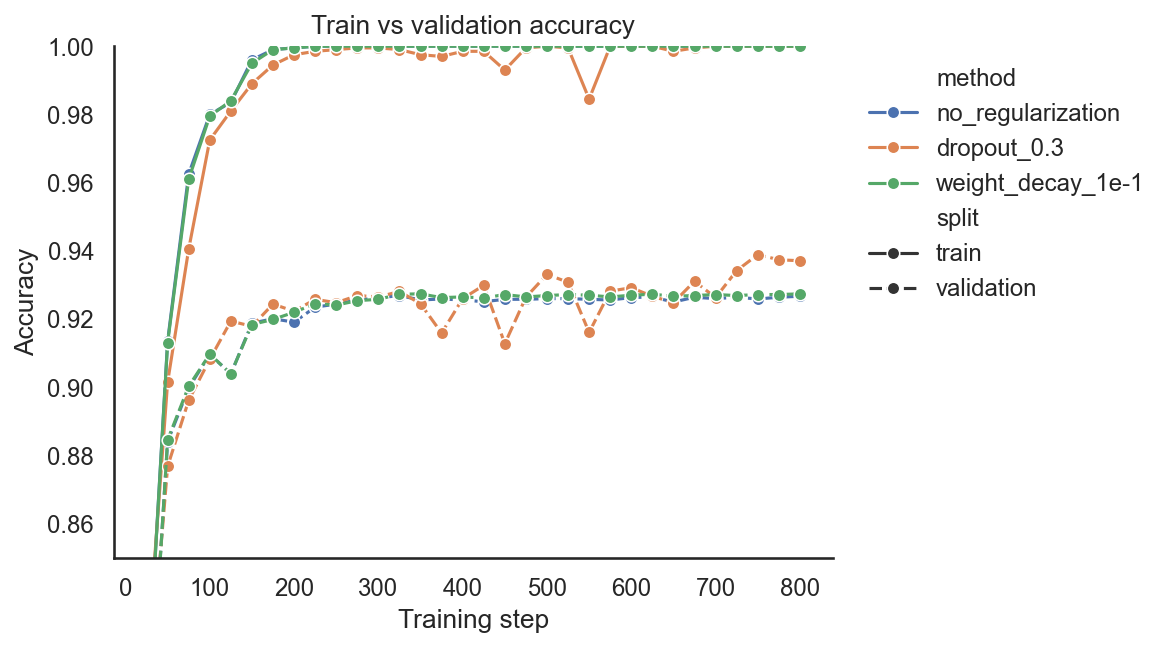

In [44]:
accuracy_curve = pd.concat(
    [
        history_df[["method", "step", "train_accuracy"]].rename(columns={"train_accuracy": "accuracy"}).assign(split="train"),
        history_df[["method", "step", "val_accuracy"]].rename(columns={"val_accuracy": "accuracy"}).assign(split="validation"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(
    data=accuracy_curve,
    x="step",
    y="accuracy",
    hue="method",
    style="split",
    marker="o",
    ax=ax,
)
ax.set_title("Train vs validation accuracy")
ax.set_xlabel("Training step")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.85, 1)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

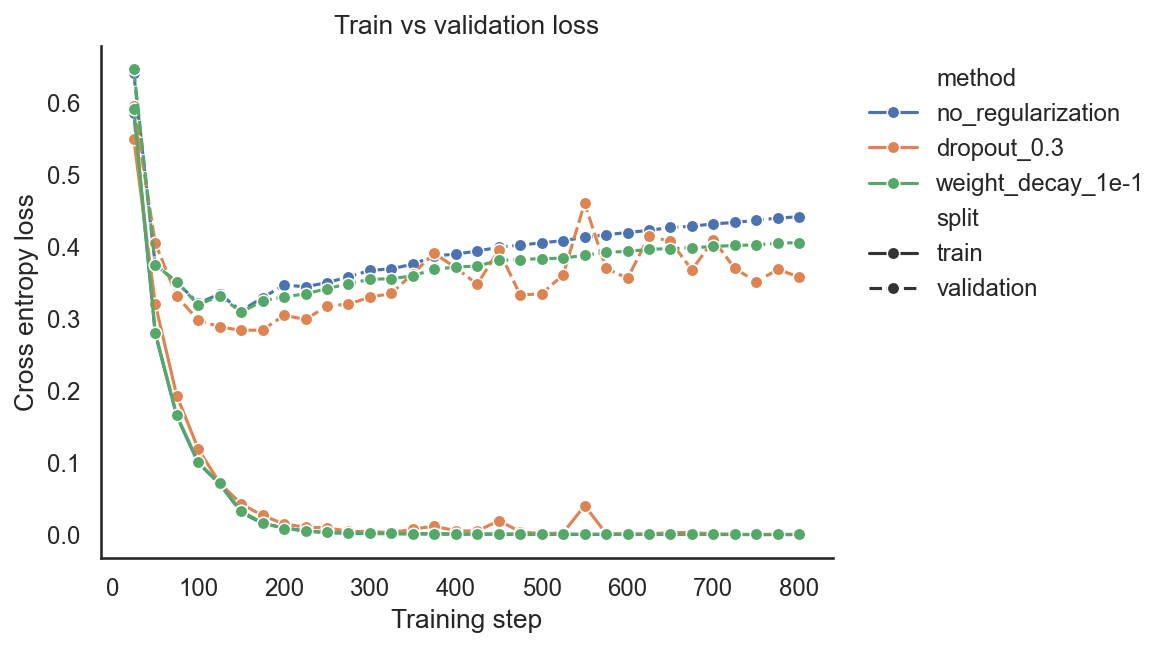

In [45]:
loss_curve = pd.concat(
    [
        history_df[["method", "step", "train_loss"]].rename(columns={"train_loss": "loss"}).assign(split="train"),
        history_df[["method", "step", "val_loss"]].rename(columns={"val_loss": "loss"}).assign(split="validation"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(
    data=loss_curve,
    x="step",
    y="loss",
    hue="method",
    style="split",
    marker="o",
    ax=ax,
)
ax.set_title("Train vs validation loss")
ax.set_xlabel("Training step")
ax.set_ylabel("Cross entropy loss")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 11. 最终 test 结果

只有在我们已经看完 validation 曲线、决定如何比较模型之后，才查看 test set。这里的 test accuracy 是最终报告结果。

In [46]:
test_results_df.sort_values("test_accuracy", ascending=False)

,method,test_loss,test_accuracy
1,dropout_0.3,0.370539,0.9381
2,weight_decay_1e-1,0.417620,0.9254
0,no_regularization,0.456062,0.9246


## 12. 总结

这个 notebook 的重点不是哪个方法一定最好，而是学会正确观察训练过程：

- train set 用来学习参数。
- validation set 用来选择模型和超参数。
- test set 用来做最后报告。
- 大网络有更强表达能力，也有更强 overfit 风险。
- dropout 和 weight decay 都是在限制模型过度依赖训练集细节。
- 如果 validation performance 不再提升，继续训练可能只是让模型更会记住 train set。

同学们可以尝试：

- 把 `TRAIN_SIZE` 改成 `1_000` 或 `10_000`。
- 把 `EPOCHS` 改成更大，例如 `30`。
- 把 `dropout_rate` 改成 `0.1`、`0.5`。
- 把 `weight_decay` 改成 `1e-5`、`1e-3`。
- 加入 data augmentation，观察 validation curve 是否更稳。

**AI 使用指引。** 复习时可以把本 notebook 的实验结果发给 AI，并问：`请根据 train/validation/test 曲线判断哪些模型 overfit，哪些 regularization 有帮助，并说明证据。` 重点是让解释依赖曲线和指标，而不是只看一个最高 accuracy。